In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
import os

DATA_PATH = "/kaggle/input/competitions/hack-rush-2026-14-cell-bone-marrow-classification"

TRAIN_PATH = os.path.join(DATA_PATH, "hour0_train/hour0_train")
TEST_PATH = os.path.join(DATA_PATH, "phase2_test_14/phase2_test_14")

print("Train folders:", os.listdir(TRAIN_PATH)[:5])
print("Test sample:", os.listdir(TEST_PATH)[:5])

Train folders: ['disease11', 'disease8', 'disease1', 'disease2', 'disease14']
Test sample: ['cp2_00032.jpg', 'cp2_00078.jpg', 'cp2_00137.jpg', 'cp2_00057.jpg', 'cp2_00052.jpg']


Image path: /kaggle/input/competitions/hack-rush-2026-14-cell-bone-marrow-classification/hour0_train/hour0_train/disease11/ART_00549.jpg
Image size: (250, 250)
Image mode: RGB


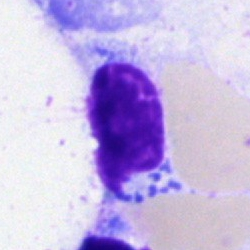

In [4]:
from PIL import Image
import os

sample_class = os.listdir(TRAIN_PATH)[0]

sample_image = os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]

img_path = os.path.join(TRAIN_PATH, sample_class, sample_image)

img = Image.open(img_path)

print("Image path:", img_path)
print("Image size:", img.size)
print("Image mode:", img.mode)

img

In [5]:
from torchvision import transforms

transform = transforms.Compose([
    
    transforms.Resize((224,224)),   # convert 250 → 224
    
    transforms.RandomHorizontalFlip(),   # augmentation
    
    transforms.RandomRotation(10),       # augmentation
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    TRAIN_PATH,
    transform=transform 
)

print("Total images:", len(train_dataset))
print("Classes:", train_dataset.classes)

Total images: 33600
Classes: ['disease1', 'disease10', 'disease11', 'disease12', 'disease13', 'disease14', 'disease2', 'disease3', 'disease4', 'disease5', 'disease6', 'disease7', 'disease8', 'disease9']


In [7]:
batch_size = 32
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)

In [8]:
from torchvision import models
import torch.nn as nn

model = models.efficientnet_b4(
    weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 14)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 178MB/s]


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler("cuda")

In [10]:
EPOCHS = 30

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in (train_loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)

    accuracy = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    scheduler.step()

Epoch 1/30 | Loss: 1.1858 | Accuracy: 0.6123
Epoch 2/30 | Loss: 0.5960 | Accuracy: 0.8008
Epoch 3/30 | Loss: 0.4191 | Accuracy: 0.8588
Epoch 4/30 | Loss: 0.2848 | Accuracy: 0.9042
Epoch 5/30 | Loss: 0.1938 | Accuracy: 0.9339
Epoch 6/30 | Loss: 0.1356 | Accuracy: 0.9545
Epoch 7/30 | Loss: 0.1000 | Accuracy: 0.9656
Epoch 8/30 | Loss: 0.0824 | Accuracy: 0.9717
Epoch 9/30 | Loss: 0.0666 | Accuracy: 0.9774
Epoch 10/30 | Loss: 0.0566 | Accuracy: 0.9814
Epoch 11/30 | Loss: 0.0465 | Accuracy: 0.9850
Epoch 12/30 | Loss: 0.0405 | Accuracy: 0.9872
Epoch 13/30 | Loss: 0.0331 | Accuracy: 0.9890
Epoch 14/30 | Loss: 0.0302 | Accuracy: 0.9910
Epoch 15/30 | Loss: 0.0265 | Accuracy: 0.9916
Epoch 16/30 | Loss: 0.0225 | Accuracy: 0.9923
Epoch 17/30 | Loss: 0.0192 | Accuracy: 0.9933
Epoch 18/30 | Loss: 0.0173 | Accuracy: 0.9938
Epoch 19/30 | Loss: 0.0150 | Accuracy: 0.9948
Epoch 20/30 | Loss: 0.0123 | Accuracy: 0.9960
Epoch 21/30 | Loss: 0.0112 | Accuracy: 0.9964
Epoch 22/30 | Loss: 0.0098 | Accuracy: 0.99

In [11]:
torch.save(model.state_dict(), "/kaggle/working/sub.pth")

print("Model saved successfully!")

Model saved successfully!


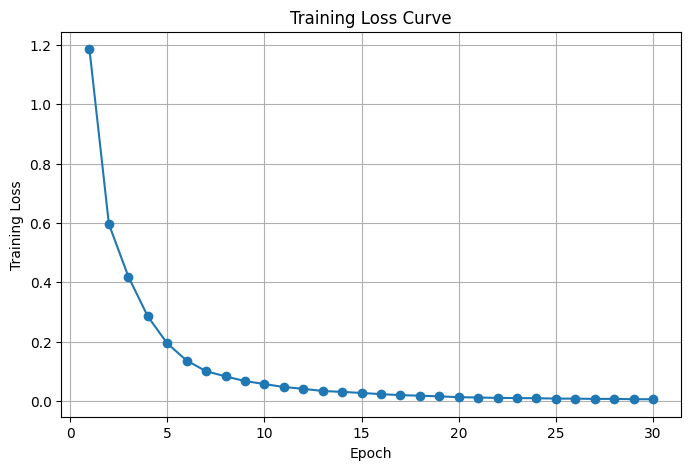

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS+1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")

plt.grid(True)

plt.show()

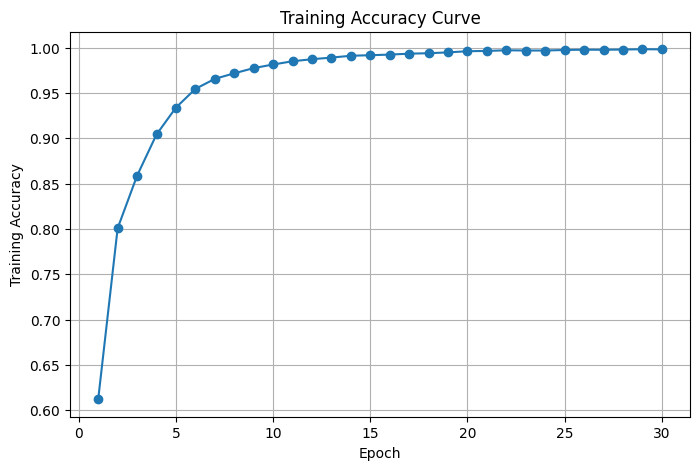

In [13]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_accuracies, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Curve")

plt.grid(True)

plt.show()

In [14]:
import pandas as pd
from PIL import Image
import os
import torch

model.to(device)
model.eval()

class_names = train_dataset.classes
test_images = sorted(os.listdir(TEST_PATH))

image_names = []
predictions = []

with torch.no_grad():

    for img_name in test_images:

        img_path = os.path.join(TEST_PATH, img_name)

        image = Image.open(img_path).convert("RGB")

        image = transform(image).unsqueeze(0).to(device)

        output = model(image)

        pred = torch.argmax(output, dim=1).item()

        predicted_class = class_names[pred]

        image_names.append(img_name)
        predictions.append(predicted_class)

submission = pd.DataFrame({
    "image_name": image_names,
    "predicted_class": predictions
})

submission.to_csv("/kaggle/working/sub.csv", index=False)

print("Submission file saved!")
submission.head()

Submission file saved!


,image_name,predicted_class
0,cp2_00001.jpg,disease1
1,cp2_00002.jpg,disease1
2,cp2_00003.jpg,disease1
3,cp2_00004.jpg,disease1
4,cp2_00005.jpg,disease1
